# Problem Statement 3 :-->


A certain organization wants an early estimate of their employee churn out rate. So the HR department gathered the data regarding the employee’s salary hike and the churn out rate in a financial year. The analytics team will have to perform an analysis and predict an estimate of employee churn based on the salary hike. Build a Simple Linear Regression model with churn out rate as the target variable. Apply necessary transformations and record the RMSE and correlation coefficient values for different models.

# Business Objectives:-->

Predict Employee Churn Rate based on Salary Hike using regression models.

Provide an early estimate to help the HR department make strategic decisions.

Ensure high accuracy in prediction to improve workforce planning and retention strategies.

Identify the relationship between Salary Hike and Churn Rate to aid decision-making.

# Constraints:-->

The model should be interpretable to help HR understand employee behavior.

Handling outliers and skewness in data is necessary before modeling.

The dataset may be limited, so careful feature engineering and transformations are required.

In [2]:
#import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [3]:
#load the dataset
df = pd.read_csv("emp_data.csv") 

In [4]:
#print 1st 5 rows to understand dataset
df.head(5)

,Salary_hike,Churn_out_rate
0,1580,92
1,1600,85
2,1610,80
3,1640,75
4,1660,72


In [5]:
#print shape of dataset
df.shape

(10, 2)

In [6]:
#print information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Salary_hike     10 non-null     int64
 1   Churn_out_rate  10 non-null     int64
dtypes: int64(2)
memory usage: 288.0 bytes


In [7]:
#print description of dataset
df.describe()

,Salary_hike,Churn_out_rate
count,10.000000,10.000000
mean,1688.600000,72.900000
std,92.096809,10.257247
min,1580.000000,60.000000
25%,1617.500000,65.750000
50%,1675.000000,71.000000
75%,1724.000000,78.750000
max,1870.000000,92.000000


In [8]:
#rename column names for ease of use
df.columns=["Salary_Hike","Churn_Rate"]

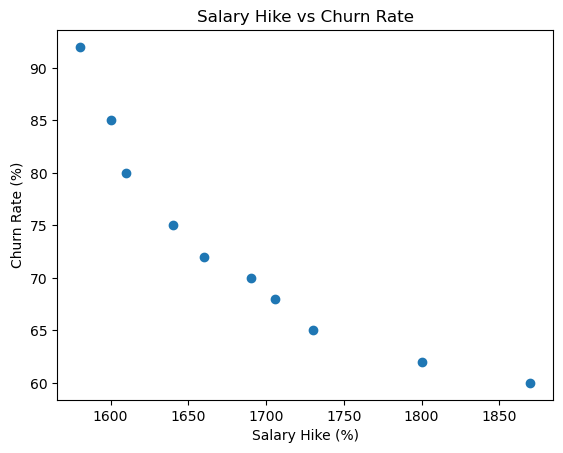

In [9]:
# Scatter plot
plt.scatter(df['Salary_Hike'], df['Churn_Rate'])
plt.xlabel("Salary Hike (%)")
plt.ylabel("Churn Rate (%)")
plt.title("Salary Hike vs Churn Rate")
plt.show()

In [10]:
# Correlation coefficient
corr = np.corrcoef(df['Salary_Hike'], df['Churn_Rate'])[0,1]
print(f"Correlation Coefficient: {corr:.4f}")

Correlation Coefficient: -0.9117


In [11]:
#model 1: Simple Linear Regression Model
model1 = smf.ols('Churn_Rate ~ Salary_Hike', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             Churn_Rate   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     39.40
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           0.000239
Time:                        14:02:41   Log-Likelihood:                -28.046
No. Observations:                  10   AIC:                             60.09
Df Residuals:                       8   BIC:                             60.70
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     244.3649     27.352      8.934      

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [12]:
# Predictions
pred1 = model1.predict(df[['Salary_Hike']])

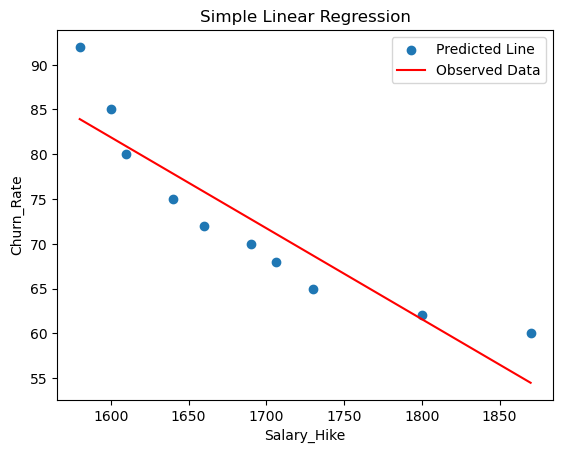

In [13]:
# Regression Line
plt.scatter(df.Salary_Hike, df.Churn_Rate)
plt.plot(df.Salary_Hike, pred1, 'r')
plt.xlabel("Salary_Hike")
plt.ylabel("Churn_Rate")
plt.title("Simple Linear Regression")
plt.legend(["Predicted Line", "Observed Data"])
plt.show()

In [14]:
# RMSE Calculation
rmse1 = np.sqrt(np.mean((df['Churn_Rate'] - pred1) ** 2))
print(f"Simple Linear Regression RMSE: {rmse1:.4f}")

Simple Linear Regression RMSE: 3.9975


In [15]:
#model 2: Log Transformation Model
df['Log_Churn'] = np.log(df['Churn_Rate'])
model2 = smf.ols('Log_Churn ~ Salary_Hike', data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              Log_Churn   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     55.26
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           7.38e-05
Time:                        14:02:41   Log-Likelihood:                 16.511
No. Observations:                  10   AIC:                            -29.02
Df Residuals:                       8   BIC:                            -28.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.6383      0.318     20.902      

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [16]:
# Predictions
pred2 = model2.predict(df[['Salary_Hike']])
pred2_at = np.exp(pred2)  # Reverse log transformation

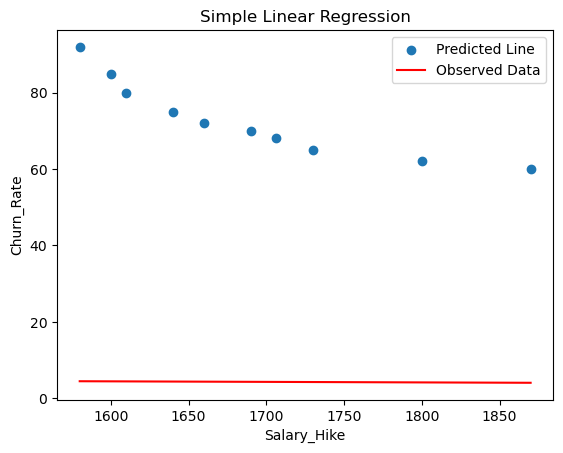

In [17]:
# Regression Line
plt.scatter(df.Salary_Hike, df.Churn_Rate)
plt.plot(df.Salary_Hike, pred2, 'r')
plt.xlabel("Salary_Hike")
plt.ylabel("Churn_Rate")
plt.title("Simple Linear Regression")
plt.legend(["Predicted Line", "Observed Data"])
plt.show()

In [18]:
# RMSE Calculation
rmse2 = np.sqrt(np.mean((df['Churn_Rate'] - pred2_at) ** 2))
print(f"Log Transformation RMSE: {rmse2:.4f}")

Log Transformation RMSE: 3.5415


In [19]:
#model 3: Polynomial Regression Model (Quadratic)
df['Salary_Hike_Sq'] = df['Salary_Hike'] ** 2
model3 = smf.ols('Churn_Rate ~ Salary_Hike + Salary_Hike_Sq', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             Churn_Rate   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     129.6
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           2.95e-06
Time:                        14:02:42   Log-Likelihood:                -18.751
No. Observations:                  10   AIC:                             43.50
Df Residuals:                       7   BIC:                             44.41
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1647.0116    228.059      7.

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [20]:
# Predictions
pred3 = model3.predict(df[['Salary_Hike', 'Salary_Hike_Sq']])

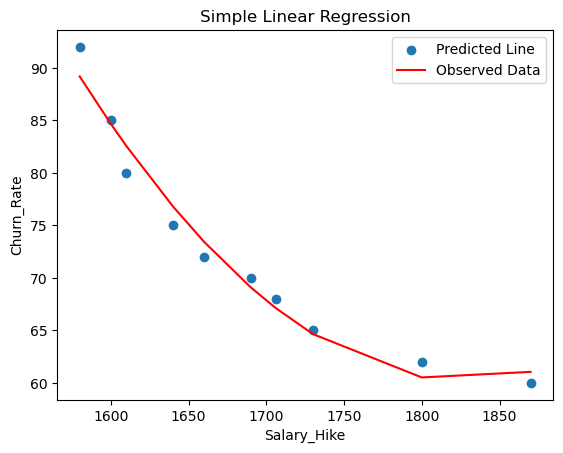

In [21]:
# Regression Line
plt.scatter(df.Salary_Hike, df.Churn_Rate)
plt.plot(df.Salary_Hike, pred3, 'r')
plt.xlabel("Salary_Hike")
plt.ylabel("Churn_Rate")
plt.title("Simple Linear Regression")
plt.legend(["Predicted Line", "Observed Data"])
plt.show()

In [22]:
# RMSE Calculation
rmse3 = np.sqrt(np.mean((df['Churn_Rate'] - pred3) ** 2))
print(f"Polynomial Regression RMSE: {rmse3:.4f}")

Polynomial Regression RMSE: 1.5780


In [23]:
#Compare RMSE Values for All Models
print("--- RMSE Comparison ---")
print(f"Simple Linear Regression RMSE: {rmse1}")
print(f"Log Transformation RMSE: {rmse2}")
print(f"Polynomial Regression RMSE: {rmse3}")

--- RMSE Comparison ---
Simple Linear Regression RMSE: 3.997528462337793
Log Transformation RMSE: 3.5415493188215756
Polynomial Regression RMSE: 1.5779753028677412


In [24]:
#Compare Correlation Coefficients
corr_log = np.corrcoef(df.Salary_Hike, np.log(df.Churn_Rate))[0, 1]
corr_poly = np.corrcoef(df.Salary_Hike, pred3)[0, 1]

print("--- Correlation Coefficient Comparison ---")
print(f"Simple Linear Regression: {corr}")
print(f"Log Transformation: {corr_log}")
print(f"Polynomial Regression: {corr_poly}")

--- Correlation Coefficient Comparison ---
Simple Linear Regression: -0.9117216186909112
Log Transformation: -0.934636070979677
Polynomial Regression: -0.9239508405656954


1. Simple Linear Regression:

RMSE = 3.9975, Correlation = -0.9117
The model shows a strong negative correlation, indicating that as salary hike increases, churn rate decreases.
However, the high RMSE suggests the model has significant prediction errors and might not capture all patterns.

2. Log Transformation Model:

RMSE = 3.5415, Correlation = -0.9346
The log transformation improves correlation slightly, suggesting a better fit than the simple linear model.
However, the RMSE is still relatively high, indicating room for improvement.

3. Polynomial Regression (Degree 2):

RMSE = 1.5779, Correlation = -0.9239
This model achieves the lowest RMSE, meaning it provides the best prediction accuracy.
The correlation remains strong, confirming that a polynomial relationship fits the data better than a linear one.

Since, Polynomial Regression is the best model as it has the lowest RMSE and effectively captures the relationship between salary hikes and churn rates.